# Feature Selection — Two-Stage Analysis
*Stage 1: Mutual Information + Spearman Correlation Filter*  
*Stage 2: SHAP (SHapley Additive exPlanations) Value Analysis*

**Goal:** Identify the best submission-time features for the quantile prediction model, using a rigorous two-stage selection process.

**Stage 1 — Filter pass:** Rank all candidate features by their statistical relationship with the target (`log_target`) using Mutual Information (captures nonlinear relationships) and Spearman Correlation (rank-based, robust to outliers). Eliminates features with genuinely no predictive relationship before any model is fit.

**Stage 2 — SHAP analysis:** Fit a LightGBM model on the filtered feature set and compute SHAP values to measure each feature's marginal contribution to individual predictions. More honest than Mean Decrease in Impurity (not biased toward high-cardinality features) and explains *why* the model uses each feature rather than just how often.

**Leakage policy:** Any feature that is not known at the time of permit submission is excluded before analysis begins. Post-submission process variables (review cycles, correction counts, reviewer assignments) are explicitly flagged and removed.

**Output:** A ranked feature recommendation list saved as `feature_selection_results.csv`, ready to inform the quantile model design.

## 0. Install & Import

In [1]:
import sys
!{sys.executable} -m pip install lightgbm shap --quiet
print('lightgbm and shap installed.')

lightgbm and shap installed.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\flori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import datetime
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import lightgbm as lgb
import shap

DATA_DIR   = Path(r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\data')
OUTPUT_DIR = Path(r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Define Candidate Features

In [3]:
df = pd.read_csv(DATA_DIR / 'master_dataset.csv')
comment_features = pd.read_csv(OUTPUT_DIR / 'comment_features.csv')
df = df.merge(comment_features, on='permitnum', how='left')

print(f'Dataset: {len(df):,} rows × {len(df.columns)} columns')

# ── Submission-time features only ─────────────────────────────────
# These are all knowable at the moment a permit application is submitted.
# Estimated project cost is EXCLUDED per liaison guidance.

CAT_CANDIDATES = [
    'permittypedesc',     # permit type — strong known signal
    'permitclass',        # permit class — strong known signal
    'zone_family',        # zoning prefix
    'review_complexity_max',  # complexity tier assigned at submission
]

NUM_CANDIDATES = [
    'latitude',
    'longitude',
    'log_housingunitsadded',
    'app_year',
    'app_month',
    'app_quarter',
    'dependentbuilding',
    # Comment features — available if comments exist at submission
    'comment_max_cycle',
    'comment_n_distinct_cycles',
    'comment_n_rows',
    'comment_n_subjects',
    'comment_n_review_types',
    'comment_has_structural',
    'comment_has_eca',
    'comment_has_design_review',
    'comment_resubmit_rate',
]

# ── Explicitly excluded leakage fields ────────────────────────────
LEAKAGE_FIELDS = [
    'total_review_cycles',      # outcome of review process
    'n_correction_cycles',      # outcome of review process
    'any_corrections_required', # outcome of review process
    'n_reviewers_assigned',     # assigned during review, not at submission
    'n_review_types',           # determined during review
    'has_rejection',            # outcome of review process
    'daysplanreviewcity',       # direct component of target
    'daysinitialplanreview',    # direct component of target
    'daysoutcorrections',       # direct component of target
    'numberreviewcycles',       # direct component of target
    'daysissuepermitcity',      # post-approval
    'estprojectcost',           # excluded per liaison — not known at submission
    'log_estprojectcost',       # excluded per liaison
]

TARGET = 'log_target'

print(f'\nCandidate categorical features : {len(CAT_CANDIDATES)}')
print(f'Candidate numeric features     : {len(NUM_CANDIDATES)}')
print(f'Excluded leakage fields        : {len(LEAKAGE_FIELDS)}')

Dataset: 14,201 rows × 90 columns

Candidate categorical features : 4
Candidate numeric features     : 16
Excluded leakage fields        : 13


## 2. Prepare Feature Matrix

Encode categoricals ordinally so all features are numeric for mutual information and SHAP analysis.

In [4]:
ALL_CANDIDATES = CAT_CANDIDATES + NUM_CANDIDATES

# Fill categorical nulls
for col in CAT_CANDIDATES:
    df[col] = df[col].fillna('Unknown').astype(str)

# Ordinal encode categoricals
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_enc = df[ALL_CANDIDATES].copy()
df_enc[CAT_CANDIDATES] = enc.fit_transform(df_enc[CAT_CANDIDATES])

y = df[TARGET].copy()

print('Feature matrix prepared.')
print(f'Shape: {df_enc.shape}')
print(f'\nNull counts:')
nulls = df_enc.isnull().sum()
print(nulls[nulls > 0].to_string())

Feature matrix prepared.
Shape: (14201, 20)

Null counts:
latitude                        19
longitude                       19
log_housingunitsadded          237
comment_max_cycle            13536
comment_n_distinct_cycles    13536
comment_n_rows               13536
comment_n_subjects           13536
comment_n_review_types       13536
comment_has_structural       13536
comment_has_eca              13536
comment_has_design_review    13536
comment_resubmit_rate        13536


## 3. Stage 1 — Filter Pass: Mutual Information & Spearman Correlation

**Mutual Information** measures the amount of information shared between each feature and the target — it captures nonlinear relationships that correlation misses. Higher = more signal.

**Spearman Correlation** measures monotonic rank-order relationship between each feature and the target. Robust to outliers and skewed distributions. Used alongside mutual information since they capture different aspects of the relationship.

In [5]:
# Mutual Information — fill nulls with -999 as a sentinel
# (mutual_info_regression requires no nulls)
X_filled = df_enc.fillna(-999)

mi_scores = mutual_info_regression(
    X_filled, y,
    discrete_features=False,
    random_state=42
)

# Spearman correlation
spearman_scores = []
for col in ALL_CANDIDATES:
    valid = df_enc[col].notna() & y.notna()
    corr, _ = spearmanr(df_enc.loc[valid, col], y[valid])
    spearman_scores.append(corr)

# Compile Stage 1 results
stage1 = pd.DataFrame({
    'feature':     ALL_CANDIDATES,
    'type':        ['categorical'] * len(CAT_CANDIDATES) + ['numeric'] * len(NUM_CANDIDATES),
    'mi_score':    mi_scores,
    'spearman_r':  spearman_scores,
    'spearman_abs': [abs(s) for s in spearman_scores],
})

# Normalize MI to 0-1 for display
stage1['mi_norm'] = stage1['mi_score'] / stage1['mi_score'].max()
stage1 = stage1.sort_values('mi_score', ascending=False).reset_index(drop=True)

print('=== Stage 1: Mutual Information + Spearman Correlation ===')
print(f"{'Feature':<35} {'Type':<12} {'MI (norm)':>10}  {'Spearman r':>11}")
print('-' * 72)
for _, row in stage1.iterrows():
    bar = '█' * int(row['mi_norm'] * 20)
    print(f"  {row['feature']:<33} {row['type']:<12} {row['mi_norm']:>10.4f}  {row['spearman_r']:>11.4f}  {bar}")

=== Stage 1: Mutual Information + Spearman Correlation ===
Feature                             Type          MI (norm)   Spearman r
------------------------------------------------------------------------
  permittypedesc                    categorical      1.0000       0.5302  ████████████████████
  review_complexity_max             categorical      0.9666       0.5119  ███████████████████
  latitude                          numeric          0.9270      -0.0168  ██████████████████
  log_housingunitsadded             numeric          0.8830       0.4841  █████████████████
  longitude                         numeric          0.7412      -0.0236  ██████████████
  zone_family                       categorical      0.5362      -0.0298  ██████████
  permitclass                       categorical      0.5019       0.1395  ██████████
  app_year                          numeric          0.4079      -0.1549  ████████
  app_month                         numeric          0.3326       0.0422  █████

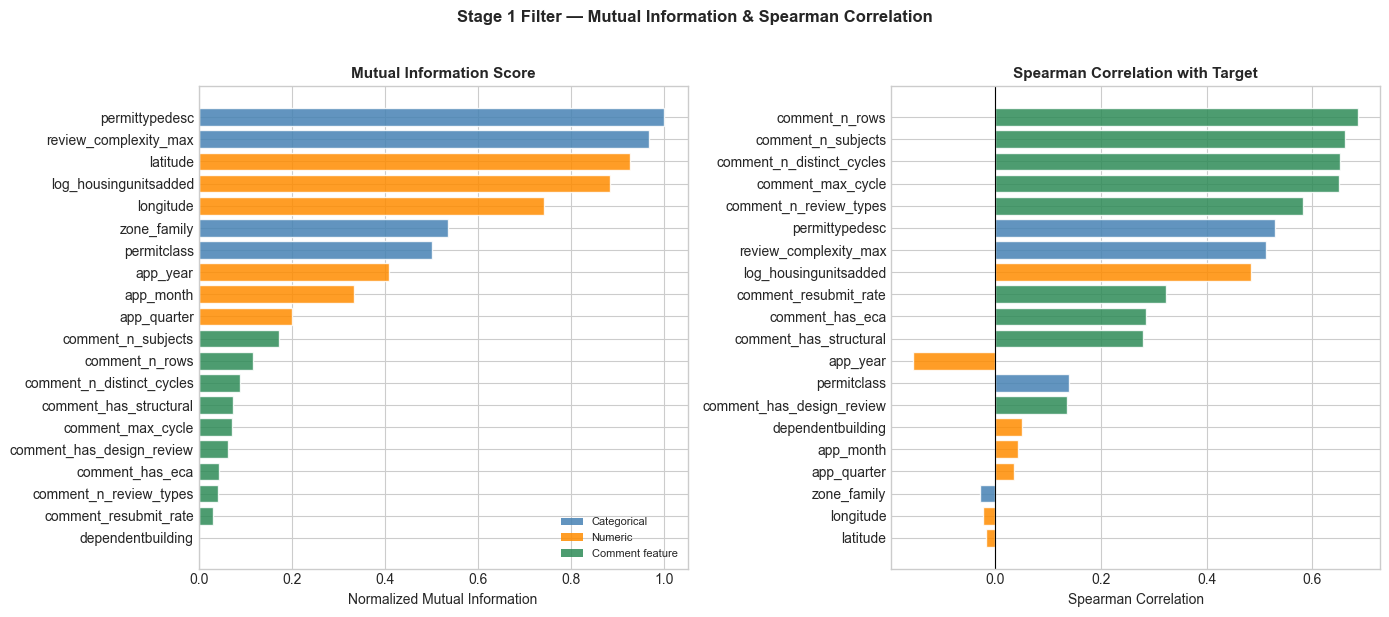

Saved: feature_selection_stage1.png


In [6]:
# --- Stage 1 visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

s1_sorted_mi = stage1.sort_values('mi_norm', ascending=True)
colors_mi = ['steelblue' if t == 'categorical' else
             ('seagreen' if 'comment' in f else 'darkorange')
             for f, t in zip(s1_sorted_mi['feature'], s1_sorted_mi['type'])]
axes[0].barh(s1_sorted_mi['feature'], s1_sorted_mi['mi_norm'], color=colors_mi, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Normalized Mutual Information', fontsize=10)
axes[0].set_title('Mutual Information Score', fontsize=11, fontweight='bold')

s1_sorted_sp = stage1.sort_values('spearman_abs', ascending=True)
colors_sp = ['steelblue' if t == 'categorical' else
             ('seagreen' if 'comment' in f else 'darkorange')
             for f, t in zip(s1_sorted_sp['feature'], s1_sorted_sp['type'])]
axes[1].barh(s1_sorted_sp['feature'], s1_sorted_sp['spearman_r'], color=colors_sp, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Spearman Correlation', fontsize=10)
axes[1].set_title('Spearman Correlation with Target', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  alpha=0.85, label='Categorical'),
    Patch(facecolor='darkorange', alpha=0.85, label='Numeric'),
    Patch(facecolor='seagreen',   alpha=0.85, label='Comment feature'),
]
axes[0].legend(handles=legend_elements, fontsize=8)

plt.suptitle('Stage 1 Filter — Mutual Information & Spearman Correlation', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_selection_stage1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_selection_stage1.png')

In [7]:
# Filter threshold — keep features with MI score above 5% of max
MI_THRESHOLD = stage1['mi_score'].max() * 0.05
stage1_passed = stage1[stage1['mi_score'] >= MI_THRESHOLD].copy()
stage1_failed = stage1[stage1['mi_score'] <  MI_THRESHOLD].copy()

print(f'MI threshold (5% of max): {MI_THRESHOLD:.4f}')
print(f'Features passing Stage 1 : {len(stage1_passed)}')
print(f'Features eliminated      : {len(stage1_failed)}')
if len(stage1_failed) > 0:
    print(f'  Eliminated: {stage1_failed["feature"].tolist()}')

MI threshold (5% of max): 0.0092
Features passing Stage 1 : 16
Features eliminated      : 4
  Eliminated: ['comment_has_eca', 'comment_n_review_types', 'comment_resubmit_rate', 'dependentbuilding']


## 4. Stage 2 — SHAP Analysis

Fit a LightGBM model on the Stage 1 filtered feature set and compute SHAP values. LightGBM is used here purely as a vehicle for SHAP analysis — it handles nulls natively, trains quickly, and produces well-calibrated SHAP values.

SHAP values answer: *for each prediction, how much did each feature push the prediction up or down from the baseline?* Averaged across all predictions, this gives a more honest importance measure than any in-model metric.

In [8]:
passed_features = stage1_passed['feature'].tolist()
passed_cat      = [f for f in passed_features if f in CAT_CANDIDATES]
passed_num      = [f for f in passed_features if f in NUM_CANDIDATES]

X_shap = df_enc[passed_features].copy()

print(f'Features entering Stage 2: {len(passed_features)}')
print(f'  Categorical: {passed_cat}')
print(f'  Numeric    : {passed_num}')

# Fit LightGBM with 5-fold CV to get stable SHAP values
kf = KFold(n_splits=5, shuffle=True, random_state=42)
shap_values_oof = np.zeros((len(X_shap), len(passed_features)))
oof_preds       = np.zeros(len(y))

lgb_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_shap), 1):
    X_train, X_val = X_shap.iloc[train_idx], X_shap.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train)

    oof_preds[val_idx] = model.predict(X_val)

    # SHAP values for validation fold
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_val)
    shap_values_oof[val_idx] = sv

    r2 = r2_score(y_val, oof_preds[val_idx])
    print(f'Fold {fold} | R²={r2:.4f}')

overall_r2 = r2_score(y.values, oof_preds)
print(f'\nOverall OOF R²: {overall_r2:.4f}')

Features entering Stage 2: 16
  Categorical: ['permittypedesc', 'review_complexity_max', 'zone_family', 'permitclass']
  Numeric    : ['latitude', 'log_housingunitsadded', 'longitude', 'app_year', 'app_month', 'app_quarter', 'comment_n_subjects', 'comment_n_rows', 'comment_n_distinct_cycles', 'comment_has_structural', 'comment_max_cycle', 'comment_has_design_review']
Fold 1 | R²=0.4333
Fold 2 | R²=0.4400
Fold 3 | R²=0.4116
Fold 4 | R²=0.4440
Fold 5 | R²=0.4480

Overall OOF R²: 0.4359


In [9]:
# Mean absolute SHAP value per feature — the primary importance metric
mean_abs_shap = np.abs(shap_values_oof).mean(axis=0)
shap_norm     = mean_abs_shap / mean_abs_shap.sum()

shap_df = pd.DataFrame({
    'feature':        passed_features,
    'mean_abs_shap':  mean_abs_shap,
    'shap_norm':      shap_norm,
    'type':           ['categorical' if f in CAT_CANDIDATES else
                       ('comment' if 'comment' in f else 'numeric')
                       for f in passed_features]
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('=== Stage 2: SHAP Feature Importance ===')
print(f"{'Rank':<5} {'Feature':<35} {'Type':<12} {'Mean |SHAP|':>12}  {'Norm':>7}")
print('-' * 75)
for i, row in shap_df.iterrows():
    bar = '█' * int(row['shap_norm'] * 50)
    print(f"  {i+1:<3}  {row['feature']:<33} {row['type']:<12} {row['mean_abs_shap']:>12.4f}  {row['shap_norm']:>7.4f}  {bar}")

=== Stage 2: SHAP Feature Importance ===
Rank  Feature                             Type          Mean |SHAP|     Norm
---------------------------------------------------------------------------
  1    permittypedesc                    categorical        0.2470   0.2515  ████████████
  2    review_complexity_max             categorical        0.1993   0.2030  ██████████
  3    app_year                          numeric            0.1543   0.1571  ███████
  4    permitclass                       categorical        0.0895   0.0911  ████
  5    latitude                          numeric            0.0713   0.0726  ███
  6    zone_family                       categorical        0.0507   0.0517  ██
  7    log_housingunitsadded             numeric            0.0490   0.0499  ██
  8    longitude                         numeric            0.0464   0.0472  ██
  9    app_month                         numeric            0.0342   0.0348  █
  10   comment_n_distinct_cycles         comment            0

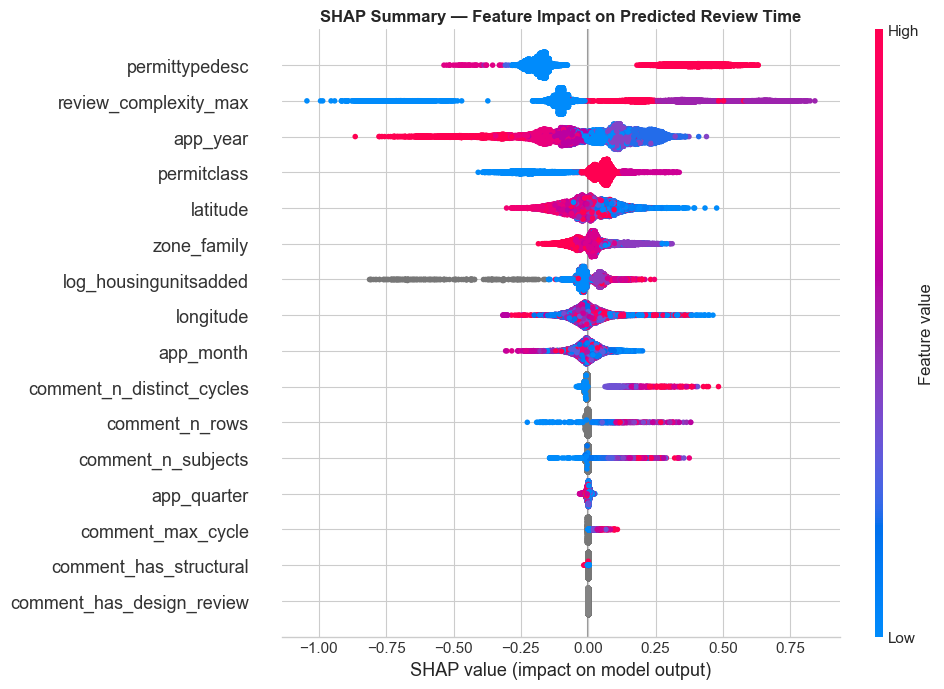

Saved: feature_selection_shap_summary.png


In [10]:
# --- SHAP summary beeswarm plot ---
# Refit on full dataset for clean SHAP plot
model_full = lgb.LGBMRegressor(**lgb_params)
model_full.fit(X_shap, y)
explainer_full = shap.TreeExplainer(model_full)
shap_vals_full = explainer_full.shap_values(X_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_full,
    X_shap,
    feature_names=passed_features,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary — Feature Impact on Predicted Review Time', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_selection_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_selection_shap_summary.png')

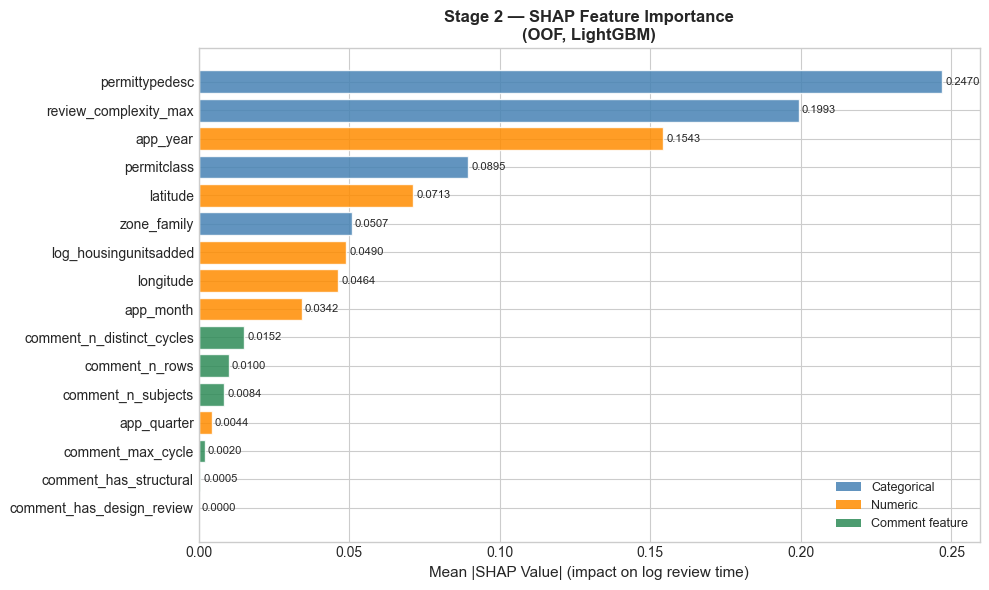

Saved: feature_selection_shap_bar.png


In [11]:
# --- SHAP bar chart colored by feature type ---
shap_sorted = shap_df.sort_values('mean_abs_shap', ascending=True)
color_map   = {'categorical': 'steelblue', 'numeric': 'darkorange', 'comment': 'seagreen'}
colors      = [color_map[t] for t in shap_sorted['type']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_sorted['feature'], shap_sorted['mean_abs_shap'], color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, shap_sorted['mean_abs_shap']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  alpha=0.85, label='Categorical'),
    Patch(facecolor='darkorange', alpha=0.85, label='Numeric'),
    Patch(facecolor='seagreen',   alpha=0.85, label='Comment feature'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel('Mean |SHAP Value| (impact on log review time)', fontsize=11)
ax.set_title('Stage 2 — SHAP Feature Importance\n(OOF, LightGBM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_selection_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_selection_shap_bar.png')

## 5. Final Feature Recommendation

Combine Stage 1 and Stage 2 scores into a single ranked recommendation. Features are recommended for inclusion in the quantile model if they pass the MI threshold and have a non-trivial SHAP contribution.

In [12]:
# SHAP threshold — keep features contributing at least 1% of total SHAP
SHAP_THRESHOLD = 0.01

final_df = stage1.merge(
    shap_df[['feature', 'mean_abs_shap', 'shap_norm']],
    on='feature', how='left'
).fillna({'mean_abs_shap': 0, 'shap_norm': 0})

final_df['stage1_pass'] = final_df['mi_score'] >= MI_THRESHOLD
final_df['stage2_pass'] = final_df['shap_norm'] >= SHAP_THRESHOLD
final_df['recommended'] = final_df['stage1_pass'] & final_df['stage2_pass']
final_df = final_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('=== Final Feature Recommendations ===')
print(f'SHAP threshold (min 1% of total): {SHAP_THRESHOLD}')
print(f'Features recommended: {final_df["recommended"].sum()}')
print(f'Features excluded   : {(~final_df["recommended"]).sum()}')
print()

rec = final_df[final_df['recommended']]
exc = final_df[~final_df['recommended']]

print('RECOMMENDED for quantile model:')
print(f"{'Feature':<35} {'Type':<12} {'MI norm':>8}  {'Spearman':>9}  {'SHAP norm':>10}")
print('-' * 78)
for _, row in rec.iterrows():
    print(f"  {row['feature']:<33} {row['type']:<12} {row['mi_norm']:>8.4f}  {row['spearman_r']:>9.4f}  {row['shap_norm']:>10.4f}")

print()
print('EXCLUDED (failed Stage 1 or Stage 2):')
for _, row in exc.iterrows():
    reason = 'MI < threshold' if not row['stage1_pass'] else 'SHAP < threshold'
    print(f"  {row['feature']:<33} {reason}")

=== Final Feature Recommendations ===
SHAP threshold (min 1% of total): 0.01
Features recommended: 11
Features excluded   : 9

RECOMMENDED for quantile model:
Feature                             Type          MI norm   Spearman   SHAP norm
------------------------------------------------------------------------------
  permittypedesc                    categorical    1.0000     0.5302      0.2515
  review_complexity_max             categorical    0.9666     0.5119      0.2030
  app_year                          numeric        0.4079    -0.1549      0.1571
  permitclass                       categorical    0.5019     0.1395      0.0911
  latitude                          numeric        0.9270    -0.0168      0.0726
  zone_family                       categorical    0.5362    -0.0298      0.0517
  log_housingunitsadded             numeric        0.8830     0.4841      0.0499
  longitude                         numeric        0.7412    -0.0236      0.0472
  app_month                      

## 6. Save Results

In [13]:
output_path = OUTPUT_DIR / 'feature_selection_results.csv'
final_df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')

Saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\feature_selection_results.csv


## 7. Diagnostic Report

In [14]:
sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — FEATURE SELECTION REPORT')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Leakage Policy ─────────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] LEAKAGE POLICY — EXCLUDED FIELDS')
lines.append(sep2)
lines.append('  The following fields are NOT submission-time features and were')
lines.append('  excluded before any analysis:')
for f in LEAKAGE_FIELDS:
    lines.append(f'    {f}')

# ── 2. Stage 1 Results ────────────────────────────────────────────
lines.append('')
lines.append('[ 2 ] STAGE 1 — MUTUAL INFORMATION + SPEARMAN CORRELATION')
lines.append(sep2)
lines.append(f'  MI threshold (5% of max): {MI_THRESHOLD:.4f}')
lines.append(f'  Candidates evaluated    : {len(stage1)}')
lines.append(f'  Passed                  : {len(stage1_passed)}')
lines.append(f'  Eliminated              : {len(stage1_failed)}')
lines.append('')
lines.append(f"  {'Feature':<35} {'MI norm':>8}  {'Spearman r':>11}  {'Pass?':>6}")
lines.append('  ' + '-' * 65)
for _, row in stage1.sort_values('mi_norm', ascending=False).iterrows():
    passed = '✓' if row['mi_score'] >= MI_THRESHOLD else '✗'
    lines.append(f"  {row['feature']:<35} {row['mi_norm']:>8.4f}  {row['spearman_r']:>11.4f}  {passed:>6}")

# ── 3. Stage 2 Results ────────────────────────────────────────────
lines.append('')
lines.append('[ 3 ] STAGE 2 — SHAP ANALYSIS (LightGBM, 5-Fold OOF)')
lines.append(sep2)
lines.append(f'  Overall OOF R²          : {overall_r2:.4f}')
lines.append(f'  SHAP threshold (1% norm): {SHAP_THRESHOLD}')
lines.append('')
lines.append(f"  {'Rank':<5} {'Feature':<35} {'Type':<12} {'Mean |SHAP|':>12}  {'Norm':>7}  {'Bar'}")
lines.append('  ' + '-' * 75)
for i, row in shap_df.iterrows():
    bar    = '█' * int(row['shap_norm'] * 50)
    passed = '✓' if row['shap_norm'] >= SHAP_THRESHOLD else '✗'
    lines.append(f"  {i+1:<5} {row['feature']:<35} {row['type']:<12} {row['mean_abs_shap']:>12.4f}  {row['shap_norm']:>7.4f}  {bar} {passed}")

# ── 4. Final Recommendations ──────────────────────────────────────
lines.append('')
lines.append('[ 4 ] FINAL FEATURE RECOMMENDATIONS')
lines.append(sep2)
lines.append(f'  Features recommended for quantile model: {final_df["recommended"].sum()}')
lines.append('')
lines.append('  RECOMMENDED:')
for _, row in rec.iterrows():
    lines.append(f"    {row['feature']:<35} {row['type']:<12} SHAP norm={row['shap_norm']:.4f}")
lines.append('')
lines.append('  EXCLUDED:')
for _, row in exc.iterrows():
    reason = 'MI < threshold' if not row['stage1_pass'] else 'SHAP < threshold'
    lines.append(f"    {row['feature']:<35} {reason}")

# ── 5. Saved Artifacts ────────────────────────────────────────────
lines.append('')
lines.append('[ 5 ] SAVED ARTIFACTS')
lines.append(sep2)
for a in [
    'feature_selection_results.csv        — full ranked results table',
    'feature_selection_stage1.png         — MI and Spearman bar charts',
    'feature_selection_shap_summary.png   — SHAP beeswarm summary plot',
    'feature_selection_shap_bar.png       — SHAP mean absolute value bar chart',
    'DiagnosticReport_FeatureSelection.txt — this report',
]:
    lines.append(f'  {a}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

report_path = OUTPUT_DIR / 'DiagnosticReport_FeatureSelection.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')

  SEATTLE PERMIT PREDICTOR — FEATURE SELECTION REPORT
  Generated: 2026-06-04 16:33:23

[ 1 ] LEAKAGE POLICY — EXCLUDED FIELDS
----------------------------------------------------------------------
  The following fields are NOT submission-time features and were
  excluded before any analysis:
    total_review_cycles
    n_correction_cycles
    any_corrections_required
    n_reviewers_assigned
    n_review_types
    has_rejection
    daysplanreviewcity
    daysinitialplanreview
    daysoutcorrections
    numberreviewcycles
    daysissuepermitcity
    estprojectcost
    log_estprojectcost

[ 2 ] STAGE 1 — MUTUAL INFORMATION + SPEARMAN CORRELATION
----------------------------------------------------------------------
  MI threshold (5% of max): 0.0092
  Candidates evaluated    : 20
  Passed                  : 16
  Eliminated              : 4

  Feature                              MI norm   Spearman r   Pass?
  -----------------------------------------------------------------
  permittyp

UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 1229: character maps to <undefined>